<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/BOA004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

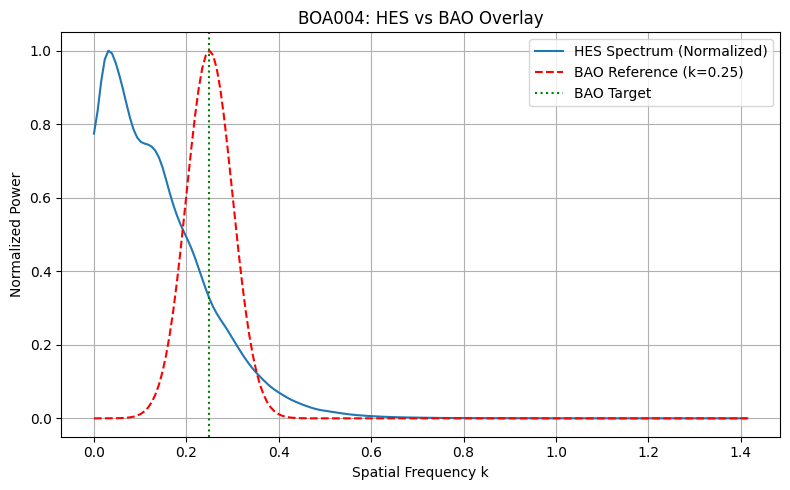

In [1]:
# BOA004: Overlay synthetic BAO reference on HES radial power spectrum
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftshift
from scipy.ndimage import gaussian_filter

# Parameters
N = 256
dt = 0.01
steps = 300
kappa = 0.1
delta = 0.05
epsilon = 0.005
gamma_0 = 0.3
xi_std = 0.01

# Initialize field
A = np.random.normal(0, 0.1, (N, N))

# Evolution loop
for t in range(steps):
    xi = np.random.normal(0, xi_std, (N, N))
    laplacian = (
        np.roll(A, 1, 0) + np.roll(A, -1, 0) +
        np.roll(A, 1, 1) + np.roll(A, -1, 1) - 4 * A
    )
    dA = (-kappa * A + delta * A**2 + epsilon * A**3 + gamma_0 * laplacian + xi) * dt
    A += np.nan_to_num(dA)

# FFT and radial power spectrum
fft_A = fftshift(fft2(A))
power_spectrum = np.abs(fft_A)**2
y, x = np.indices((N, N))
center = (N // 2, N // 2)
r = np.sqrt((x - center[1])**2 + (y - center[0])**2)
r = r.astype(np.int32)
tbin = np.bincount(r.ravel(), power_spectrum.ravel())
nr = np.bincount(r.ravel())
radial_ps = tbin / (nr + 1e-10)
k_vals = np.arange(len(radial_ps)) / (N / 2)
radial_ps_smooth = gaussian_filter(radial_ps, sigma=2)

# Synthetic BAO reference curve (Gaussian peak at k=0.25)
def bao_reference(k, a=1.0, k0=0.25, sigma=0.05):
    return a * np.exp(-(k - k0)**2 / (2 * sigma**2))

bao_curve = bao_reference(k_vals)

# Plot overlay
plt.figure(figsize=(8, 5))
plt.plot(k_vals, radial_ps_smooth / np.max(radial_ps_smooth), label='HES Spectrum (Normalized)')
plt.plot(k_vals, bao_curve, 'r--', label='BAO Reference (k=0.25)')
plt.axvline(x=0.25, color='g', linestyle=':', label='BAO Target')
plt.xlabel('Spatial Frequency k')
plt.ylabel('Normalized Power')
plt.title('BOA004: HES vs BAO Overlay')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
